In [1]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv("/kaggle/input/datasets/ridwanul02/usa-housing-training-testing/USA_Housing.csv")
df.shape

(5000, 7)

In [2]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df_clean = df.drop(columns=["Address", "Avg. Area Number of Bedrooms"])

In [4]:
df_clean.shape

(5000, 5)

In [5]:
X = df_clean.drop(columns=["Price"])
Y = df_clean["Price"]

In [6]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, Y_train_val, Y_test = train_test_split(
    X, Y, test_size=0.4, random_state=42
)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_val, Y_train_val, test_size=0.5, random_state=42
)

print(f"Training: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")


Training: 1500 | Validation: 1500 | Test: 2000


In [7]:
all_results = []

In [8]:
LR_model = make_pipeline(StandardScaler(), LinearRegression())
LR_model.fit(X_train, Y_train)
LR_train = LR_model.predict(X_train)
LR_val = LR_model.predict(X_val)
print("=== Linear Regression ===")
print(f"Train R2: {r2_score(Y_train, LR_train)}")
print(f"Validation MSE: {mean_squared_error(Y_val, LR_val):.4f}")
print(f"Validation R²: {r2_score(Y_val, LR_val):.4f}\n")
all_results.append({
    "Model Name": "Linear Regression",
    "Train R2": r2_score(Y_train, LR_train),
    "Validation R2": r2_score(Y_val, LR_val),
    "Validation MSE": mean_squared_error(Y_val, LR_val),
})

=== Linear Regression ===
Train R2: 0.9146792709726512
Validation MSE: 10033118427.5217
Validation R²: 0.9227



In [9]:
for degree in [2, 3]:
    PR_model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), StandardScaler(), LinearRegression(),)
    PR_model.fit(X_train, Y_train)
    PR_train = PR_model.predict(X_train)
    PR_val = PR_model.predict(X_val)
    print("=== Polynomial Regression Experiments ===")
    print(f"Degree {degree}:")
    print(f"Train R2: {r2_score(Y_train, PR_train)}")
    print(f"Validation MSE: {mean_squared_error(Y_val, PR_val):.4f}")
    print(f"Validation R²: {r2_score(Y_val, PR_val):.4f}")
    all_results.append({
        "Model Name": f"Polynomial Regression (Degree {degree})",
        "Train R2": r2_score(Y_train, PR_train),
        "Validation R2": r2_score(Y_val, PR_val),
        "Validation MSE": mean_squared_error(Y_val, PR_val),
    })
print()

=== Polynomial Regression Experiments ===
Degree 2:
Train R2: 0.915257053719906
Validation MSE: 10141027279.9257
Validation R²: 0.9218
=== Polynomial Regression Experiments ===
Degree 3:
Train R2: 0.9175980597203334
Validation MSE: 10542533055.8055
Validation R²: 0.9187



In [10]:
for degree in [1, 2, 3]:
    for alpha in [0.001, 0.01, 0.1, 1.0, 10.0]:
        Ridge_model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), StandardScaler(), Ridge(alpha=alpha))
        Ridge_model.fit(X_train, Y_train)
        Ridge_train = Ridge_model.predict(X_train)
        Ridge_val = Ridge_model.predict(X_val)
        print("=== Ridge Regression Experiments ===")
        print(f"Degree {degree}, Alpha {alpha}:")
        print(f"Train R2: {r2_score(Y_train, Ridge_train)}")
        print(f"Validation MSE: {mean_squared_error(Y_val, Ridge_val):.4f}")
        print(f"Validation R²: {r2_score(Y_val, Ridge_val):.4f}")
        all_results.append({
            "Model Name": f"Ridge (Degree {degree}, Alpha {alpha})",
            "Train R2": r2_score(Y_train, Ridge_train),
            "Validation R2": r2_score(Y_val, Ridge_val),
            "Validation MSE": mean_squared_error(Y_val, Ridge_val),
        })
print()

=== Ridge Regression Experiments ===
Degree 1, Alpha 0.001:
Train R2: 0.9146792709722165
Validation MSE: 10033116810.2265
Validation R²: 0.9227
=== Ridge Regression Experiments ===
Degree 1, Alpha 0.01:
Train R2: 0.9146792709291756
Validation MSE: 10033102259.9100
Validation R²: 0.9227
=== Ridge Regression Experiments ===
Degree 1, Alpha 0.1:
Train R2: 0.9146792666256249
Validation MSE: 10032957285.3515
Validation R²: 0.9227
=== Ridge Regression Experiments ===
Degree 1, Alpha 1.0:
Train R2: 0.9146788368101063
Validation MSE: 10031560328.1256
Validation R²: 0.9227
=== Ridge Regression Experiments ===
Degree 1, Alpha 10.0:
Train R2: 0.9146363893095054
Validation MSE: 10022798056.7419
Validation R²: 0.9227
=== Ridge Regression Experiments ===
Degree 2, Alpha 0.001:
Train R2: 0.9152570535967076
Validation MSE: 10141013918.3438
Validation R²: 0.9218
=== Ridge Regression Experiments ===
Degree 2, Alpha 0.01:
Train R2: 0.9152570414566286
Validation MSE: 10140895607.4289
Validation R²: 0.9218

In [11]:
for degree in [1, 2, 3]:
    for alpha in [0.001, 0.01, 0.1, 1.0, 10.0]:
        Lasso_model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), StandardScaler(), Lasso(alpha=alpha, max_iter=100000, random_state=42))
        Lasso_model.fit(X_train, Y_train)
        Lasso_train = Lasso_model.predict(X_train)
        Lasso_val = Lasso_model.predict(X_val)
        print("=== Lasso Regression Experiments ===")
        print(f"Degree {degree}, Alpha {alpha}:")
        print(f"Train R2: {r2_score(Y_train, Lasso_train)}")
        print(f"  Validation MSE: {mean_squared_error(Y_val, Lasso_val):.4f}")
        print(f"  Validation R²: {r2_score(Y_val, Lasso_val):.4f}")
        all_results.append({
            "Model Name": f"Lasso (Degree {degree}, Alpha {alpha})",
            "Train R2": r2_score(Y_train, Lasso_train),
            "Validation R2": r2_score(Y_val, Lasso_val),
            "Validation MSE": mean_squared_error(Y_val, Lasso_val),
        })
print()

=== Lasso Regression Experiments ===
Degree 1, Alpha 0.001:
Train R2: 0.9146792709726512
  Validation MSE: 10033118416.5800
  Validation R²: 0.9227
=== Lasso Regression Experiments ===
Degree 1, Alpha 0.01:
Train R2: 0.9146792709726479
  Validation MSE: 10033118318.6452
  Validation R²: 0.9227
=== Lasso Regression Experiments ===
Degree 1, Alpha 0.1:
Train R2: 0.9146792709723186
  Validation MSE: 10033117339.3368
  Validation R²: 0.9227
=== Lasso Regression Experiments ===
Degree 1, Alpha 1.0:
Train R2: 0.9146792709392828
  Validation MSE: 10033107500.6682
  Validation R²: 0.9227
=== Lasso Regression Experiments ===
Degree 1, Alpha 10.0:
Train R2: 0.9146792676449846
  Validation MSE: 10033010003.1471
  Validation R²: 0.9227
=== Lasso Regression Experiments ===
Degree 2, Alpha 0.001:
Train R2: 0.915257053719891
  Validation MSE: 10141026726.4752
  Validation R²: 0.9218
=== Lasso Regression Experiments ===
Degree 2, Alpha 0.01:
Train R2: 0.915257053718415
  Validation MSE: 10141021745.62

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.670e+12, tolerance: 1.861e+10
  model = cd_fast.enet_coordinate_descent(


=== Lasso Regression Experiments ===
Degree 3, Alpha 0.001:
Train R2: 0.9175686848521895
  Validation MSE: 10543220306.3059
  Validation R²: 0.9187


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.648e+12, tolerance: 1.861e+10
  model = cd_fast.enet_coordinate_descent(


=== Lasso Regression Experiments ===
Degree 3, Alpha 0.01:
Train R2: 0.9175687821445139
  Validation MSE: 10543072370.7092
  Validation R²: 0.9187


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.428e+12, tolerance: 1.861e+10
  model = cd_fast.enet_coordinate_descent(


=== Lasso Regression Experiments ===
Degree 3, Alpha 0.1:
Train R2: 0.9175697051574133
  Validation MSE: 10541596458.2096
  Validation R²: 0.9187


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.231e+12, tolerance: 1.861e+10
  model = cd_fast.enet_coordinate_descent(


=== Lasso Regression Experiments ===
Degree 3, Alpha 1.0:
Train R2: 0.9175738421722067
  Validation MSE: 10527401143.0349
  Validation R²: 0.9189
=== Lasso Regression Experiments ===
Degree 3, Alpha 10.0:
Train R2: 0.9172827298673762
  Validation MSE: 10364331757.3245
  Validation R²: 0.9201



In [12]:
for n_neighbours in [1, 3, 5, 7, 9, 11]:
    knn_model = make_pipeline(StandardScaler(),KNeighborsRegressor(n_neighbors=n_neighbours))
    knn_model.fit(X_train, Y_train)
    knn_train = knn_model.predict(X_train)
    knn_val = knn_model.predict(X_val)
    print("=== KNN Regressor Experiments ===")
    print(f"k = {n_neighbours}:")
    print(f"Train R2: {r2_score(Y_train, knn_train)}")
    print(f"Validation MSE: {mean_squared_error(Y_val, knn_val):.4f}")
    print(f"Validation R²: {r2_score(Y_val, knn_val):.4f}")
    all_results.append({
        "Model Name": f"KNN (k={n_neighbours})",
        "Train R2": r2_score(Y_train, knn_train),
        "Validation R2": r2_score(Y_val, knn_val),
        "Validation MSE": mean_squared_error(Y_val, knn_val),
    })

=== KNN Regressor Experiments ===
k = 1:
Train R2: 1.0
Validation MSE: 28078252227.8474
Validation R²: 0.7836
=== KNN Regressor Experiments ===
k = 3:
Train R2: 0.9263160130394712
Validation MSE: 18663327687.6500
Validation R²: 0.8562
=== KNN Regressor Experiments ===
k = 5:
Train R2: 0.9102197042909309
Validation MSE: 16544630213.2365
Validation R²: 0.8725
=== KNN Regressor Experiments ===
k = 7:
Train R2: 0.901665075220564
Validation MSE: 15713486290.7383
Validation R²: 0.8789
=== KNN Regressor Experiments ===
k = 9:
Train R2: 0.8971763715420289
Validation MSE: 15868620142.0130
Validation R²: 0.8777
=== KNN Regressor Experiments ===
k = 11:
Train R2: 0.8934034721550438
Validation MSE: 16061312655.5597
Validation R²: 0.8762


In [13]:
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values(
    by="Validation R2", ascending=False
).reset_index(drop=True)
comparison_df

,Model Name,Train R2,Validation R2,Validation MSE
0,"Ridge (Degree 1, Alpha 10.0)",0.914636,0.922749,1.002280e+10
1,"Ridge (Degree 1, Alpha 1.0)",0.914679,0.922681,1.003156e+10
2,"Ridge (Degree 1, Alpha 0.1)",0.914679,0.922670,1.003296e+10
3,"Lasso (Degree 1, Alpha 10.0)",0.914679,0.922670,1.003301e+10
4,"Ridge (Degree 1, Alpha 0.01)",0.914679,0.922669,1.003310e+10
5,"Lasso (Degree 1, Alpha 1.0)",0.914679,0.922669,1.003311e+10
6,"Ridge (Degree 1, Alpha 0.001)",0.914679,0.922669,1.003312e+10
7,"Lasso (Degree 1, Alpha 0.1)",0.914679,0.922669,1.003312e+10
8,"Lasso (Degree 1, Alpha 0.01)",0.914679,0.922669,1.003312e+10
9,"Lasso (Degree 1, Alpha 0.001)",0.914679,0.922669,1.003312e+10


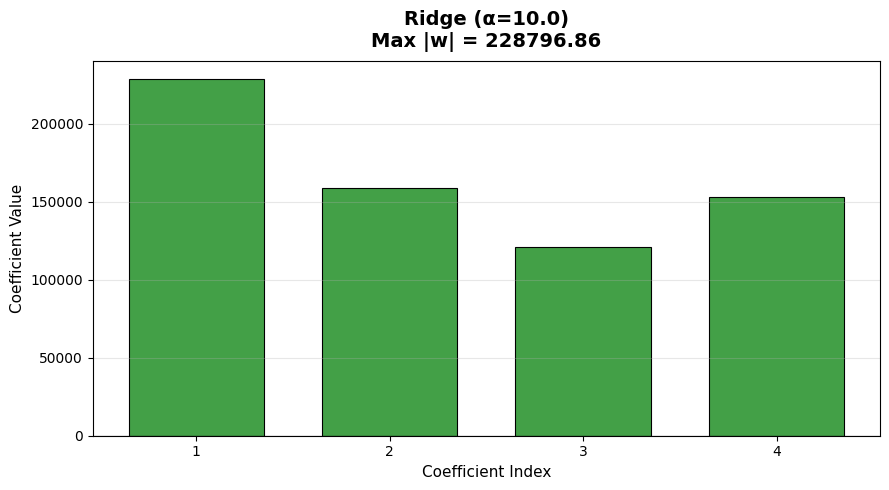

In [14]:
import matplotlib.pyplot as plt
import numpy as np

final_model = make_pipeline(
    PolynomialFeatures(degree=1, include_bias=False),
    StandardScaler(),
    Ridge(alpha=10.0),
)
final_model.fit(X_train, Y_train)

ridge_coefs = final_model[-1].coef_
if ridge_coefs.ndim > 1:
    ridge_coefs = ridge_coefs.flatten()
max_w = np.max(np.abs(ridge_coefs))

plt.figure(figsize=(9, 5))
plt.bar(
    range(1, len(ridge_coefs) + 1),
    ridge_coefs,
    color="#43a047", 
    edgecolor="black",
    linewidth=0.8,
    width=0.7,
)

plt.title(
    f"Ridge (α=10.0)\nMax |w| = {max_w:.2f}",
    fontweight="bold",
    fontsize=14,
    pad=10,
)
plt.xlabel("Coefficient Index", fontsize=11)
plt.ylabel("Coefficient Value", fontsize=11)

plt.grid(axis="y", linestyle="-", alpha=0.3)
plt.axhline(0, color="black", linewidth=0.8)  

plt.xticks(range(1, len(ridge_coefs) + 1))

plt.tight_layout()
plt.show()

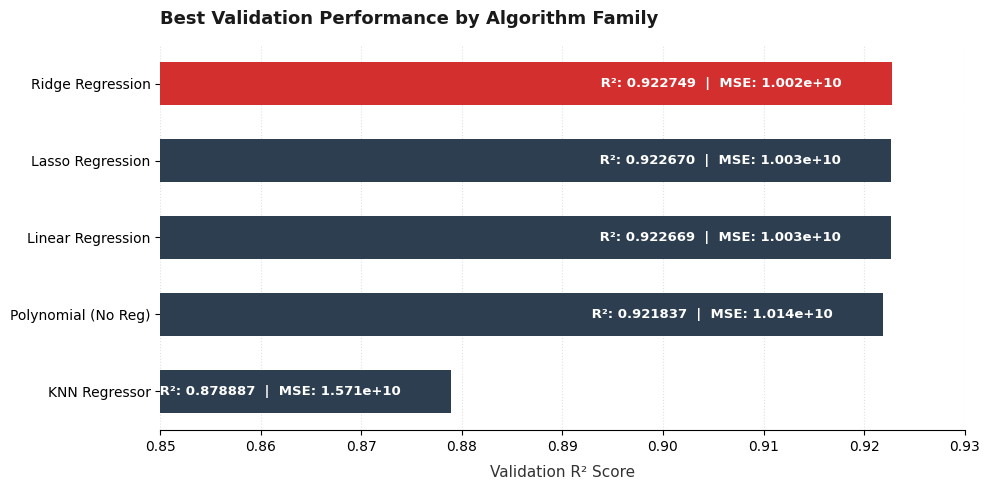

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def get_category(name):
    if "Ridge" in name:
        return "Ridge Regression"
    elif "Lasso" in name:
        return "Lasso Regression"
    elif "Polynomial" in name:
        return "Polynomial (No Reg)"
    elif "KNN" in name:
        return "KNN Regressor"
    return "Linear Regression"


comparison_df["Category"] = comparison_df["Model Name"].apply(get_category)
top_per_family = (
    comparison_df.loc[
        comparison_df.groupby("Category")["Validation R2"].idxmax()
    ]
    .sort_values(by="Validation R2", ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))

categories = top_per_family["Category"]
r2_scores = top_per_family["Validation R2"]
mse_scores = top_per_family["Validation MSE"]
colors = [
    "#d32f2f" if cat == "Ridge Regression" else "#2c3e50" for cat in categories
]

bars = ax.barh(
    categories, r2_scores, color=colors, height=0.55, edgecolor="none"
)
for bar, r2, mse in zip(bars, r2_scores, mse_scores):
    width = bar.get_width()
    label = f" R²: {r2:.6f}  |  MSE: {mse:.3e}"
    ax.text(
        width - 0.005,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha="right",
        color="white",
        fontweight="bold",
        fontsize=9.5,
    )
ax.set_title(
    "Best Validation Performance by Algorithm Family",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
    color="#1a1a1a",
)
ax.set_xlabel("Validation R² Score", fontsize=11, labelpad=8, color="#333333")
ax.set_xlim(0.85, 0.93)
ax.grid(axis="x", linestyle=":", alpha=0.6, color="#cccccc")
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Final Model Selection & Evaluation

#### **Selected Final Model**
* **Model:** Ridge Regression (`degree=1`, `alpha=10.0`)
* **Train $R^2$:** `0.914636`
* **Validation $R^2$:** `0.922749`
* **Validation MSE:** `1.002280e+10`

---

#### **Key Insights & Decision Rationale**

* **Top Validation Performance:** Out of all 40 tested configurations, **Ridge Regression (`degree=1`, `alpha=10.0`)** achieved the highest **Validation $R^2$** (`0.922749`) and the lowest **Validation MSE** (`1.002280e+10`).
* **Connection to EDA:** Linear features (`degree=1`) consistently outperformed higher-order polynomials across all models, confirming our EDA finding that the primary features share strong linear relationships with the target variable without needing complex non-linear transformations.
* **Overfitting & Generalization Check:** 
  * The **Train $R^2$** (`0.914636`) and **Validation $R^2$** (`0.922749`) are extremely close, indicating that the model **generalizes exceptionally well** to new unseen data without memorizing training noise.
  * In contrast, models like **KNN ($k=1$)** exhibited severe overfitting, reaching a **Train $R^2$ of `1.000000`** but dropping sharply to a **Validation $R^2$ of `0.783585`**.

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

final_model = make_pipeline(PolynomialFeatures(degree=1, include_bias=False),StandardScaler(),Ridge(alpha=10.0),)

final_model.fit(X_train, Y_train)

test_predictions = final_model.predict(X_test)

test_r2 = r2_score(Y_test, test_predictions)
test_mse = mean_squared_error(Y_test, test_predictions)

print(f"Test R2: {test_r2:.6f}")
print(f"Test MSE: {test_mse:.6e}")

Test R2: 0.916540
Test MSE: 1.010884e+10


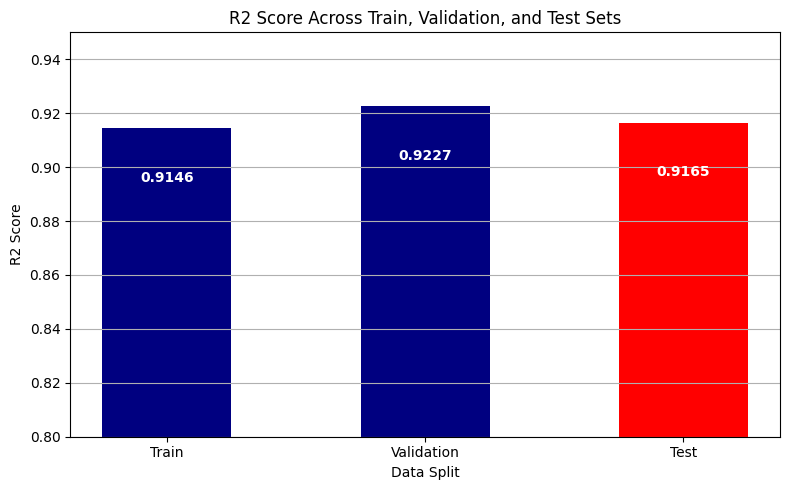

In [17]:
splits = ["Train", "Validation", "Test"]
r2_scores = [0.914600, 0.922749, 0.916540]

plt.figure(figsize=(8, 5))
plt.bar(splits, r2_scores, color=["navy", "navy", "red"], width=0.5)

for i in range(len(splits)):
    plt.text(i, r2_scores[i] - 0.02, f"{r2_scores[i]:.4f}", ha="center", color="white", fontweight="bold")

plt.title("R2 Score Across Train, Validation, and Test Sets")
plt.xlabel("Data Split")
plt.ylabel("R2 Score")
plt.ylim(0.8, 0.95)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [18]:
import joblib

joblib.dump(final_model, "best_model.pkl")

['best_model.pkl']